# Cross Validation: Visual Intuition
### Reliable Model Evaluation

**Cross Validation = Train & test on different data splits**
- Better performance estimate
- Reduces variance
- Uses all data for both training and testing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("bright")
np.random.seed(42)

## 1. The Problem: Single Train-Test Split
**Too dependent on which samples you pick!**

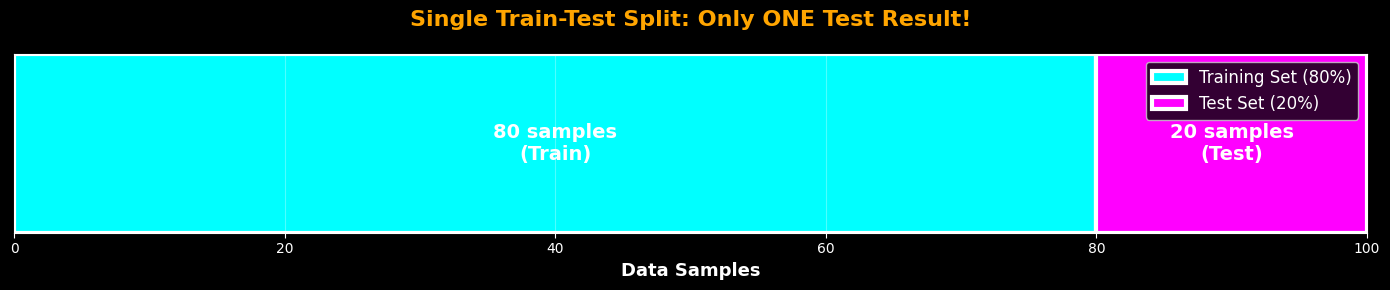

Problem with Single Split:
✗ Only one test score - could be lucky or unlucky!
✗ 20% of data never used for training
✗ High variance in performance estimate
✗ What if test set happens to be easy/hard?


In [2]:
# Visualize single train-test split
n_samples = 100
train_size = 0.8
n_train = int(n_samples * train_size)

fig, ax = plt.subplots(figsize=(14, 3))

# Draw train set
train_rect = Rectangle((0, 0), n_train, 1, facecolor='cyan', 
                       edgecolor='white', linewidth=3, label='Training Set (80%)')
ax.add_patch(train_rect)

# Draw test set
test_rect = Rectangle((n_train, 0), n_samples - n_train, 1, facecolor='magenta', 
                      edgecolor='white', linewidth=3, label='Test Set (20%)')
ax.add_patch(test_rect)

# Add text
ax.text(n_train/2, 0.5, f'{n_train} samples\n(Train)', ha='center', va='center',
       fontsize=14, fontweight='bold', color='white')
ax.text(n_train + (n_samples-n_train)/2, 0.5, f'{n_samples-n_train} samples\n(Test)', 
       ha='center', va='center', fontsize=14, fontweight='bold', color='white')

ax.set_xlim(0, n_samples)
ax.set_ylim(0, 1)
ax.set_xlabel('Data Samples', fontsize=13, fontweight='bold')
ax.set_title('Single Train-Test Split: Only ONE Test Result!', 
            fontsize=16, fontweight='bold', color='orange', pad=20)
ax.legend(fontsize=12, loc='upper right')
ax.set_yticks([])
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Problem with Single Split:")
print("="*60)
print("✗ Only one test score - could be lucky or unlucky!")
print("✗ 20% of data never used for training")
print("✗ High variance in performance estimate")
print("✗ What if test set happens to be easy/hard?")
print("="*60)

## 2. The Solution: K-Fold Cross Validation
**Test on different splits, average the results**

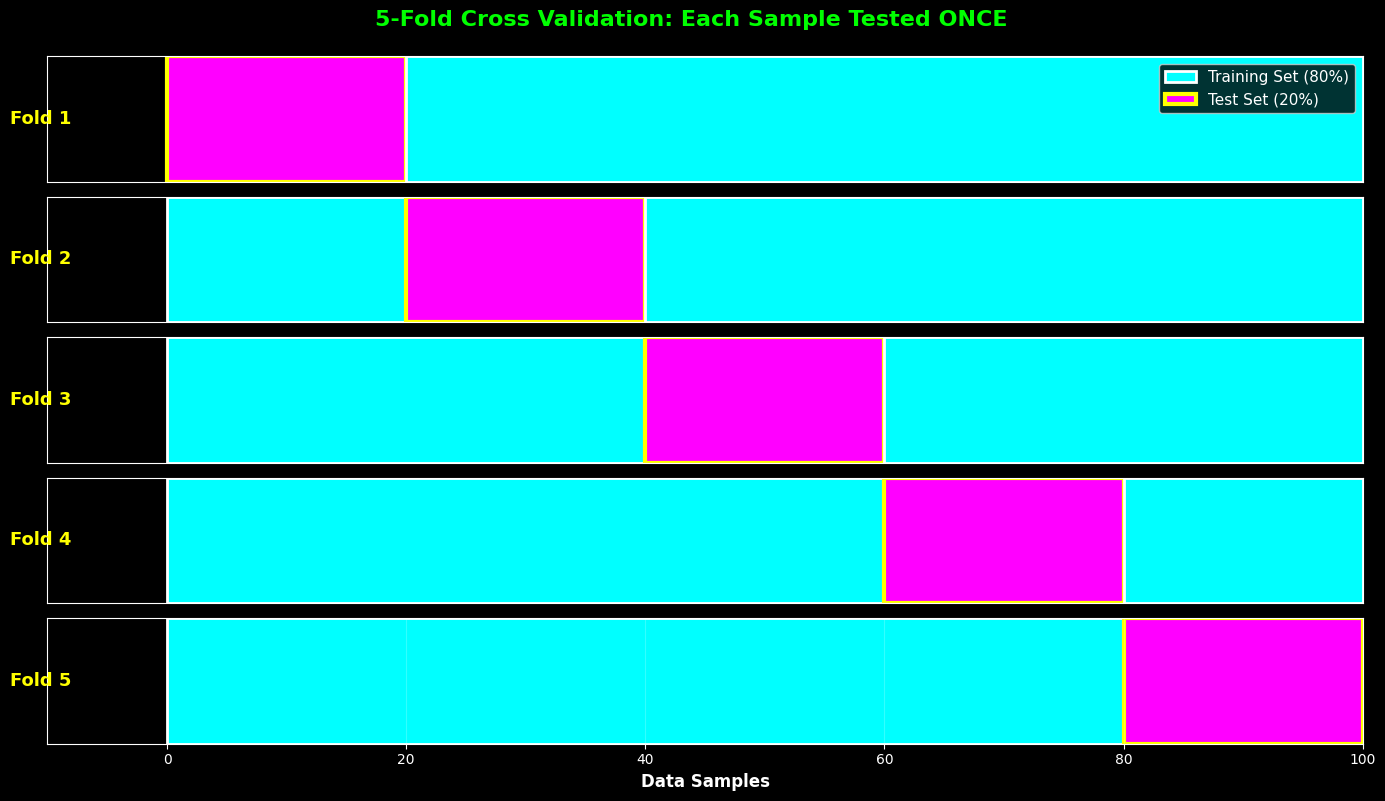


Key Insight:
✓ Each fold: 80% train, 20% test
✓ Every sample gets tested EXACTLY ONCE
✓ 5 different test scores → Average them!
✓ More reliable estimate of model performance


In [3]:
# Visualize 5-fold cross validation
n_samples = 100
k = 5
fold_size = n_samples // k

fig, axes = plt.subplots(k, 1, figsize=(14, 8))

for i, ax in enumerate(axes):
    # Calculate fold boundaries
    test_start = i * fold_size
    test_end = (i + 1) * fold_size
    
    # Draw training folds (before test)
    if test_start > 0:
        train_rect1 = Rectangle((0, 0), test_start, 1, facecolor='cyan', 
                               edgecolor='white', linewidth=2)
        ax.add_patch(train_rect1)
    
    # Draw test fold
    test_rect = Rectangle((test_start, 0), fold_size, 1, facecolor='magenta', 
                          edgecolor='yellow', linewidth=3)
    ax.add_patch(test_rect)
    
    # Draw training folds (after test)
    if test_end < n_samples:
        train_rect2 = Rectangle((test_end, 0), n_samples - test_end, 1, 
                               facecolor='cyan', edgecolor='white', linewidth=2)
        ax.add_patch(train_rect2)
    
    # Add labels
    ax.text(-8, 0.5, f'Fold {i+1}', ha='right', va='center',
           fontsize=13, fontweight='bold', color='yellow')
    
    ax.set_xlim(-10, n_samples)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    
    if i == k-1:
        ax.set_xlabel('Data Samples', fontsize=12, fontweight='bold')
    else:
        ax.set_xticks([])
    
    ax.grid(axis='x', alpha=0.2)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='cyan', edgecolor='white', linewidth=2, label='Training Set (80%)'),
    Patch(facecolor='magenta', edgecolor='yellow', linewidth=3, label='Test Set (20%)')
]
axes[0].legend(handles=legend_elements, fontsize=11, loc='upper right')

plt.suptitle('5-Fold Cross Validation: Each Sample Tested ONCE', 
            fontsize=16, fontweight='bold', color='lime', y=0.995)
plt.tight_layout()
plt.show()

print("\nKey Insight:")
print("="*60)
print("✓ Each fold: 80% train, 20% test")
print("✓ Every sample gets tested EXACTLY ONCE")
print("✓ 5 different test scores → Average them!")
print("✓ More reliable estimate of model performance")
print("="*60)

## 3. Why Cross Validation is Better
**Variance reduction through averaging**

Performance Comparison:
Single Split (50 trials):
  Mean: 0.789
  Std:  0.070 ⚠️ HIGH variance!
  Range: [0.550, 0.950]

5-Fold CV (50 trials):
  Mean: 0.790
  Std:  0.000 ✓ LOWER variance!
  Range: [0.790, 0.790]


/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_3140/1864187177.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([single_split_scores, cv_scores_all],


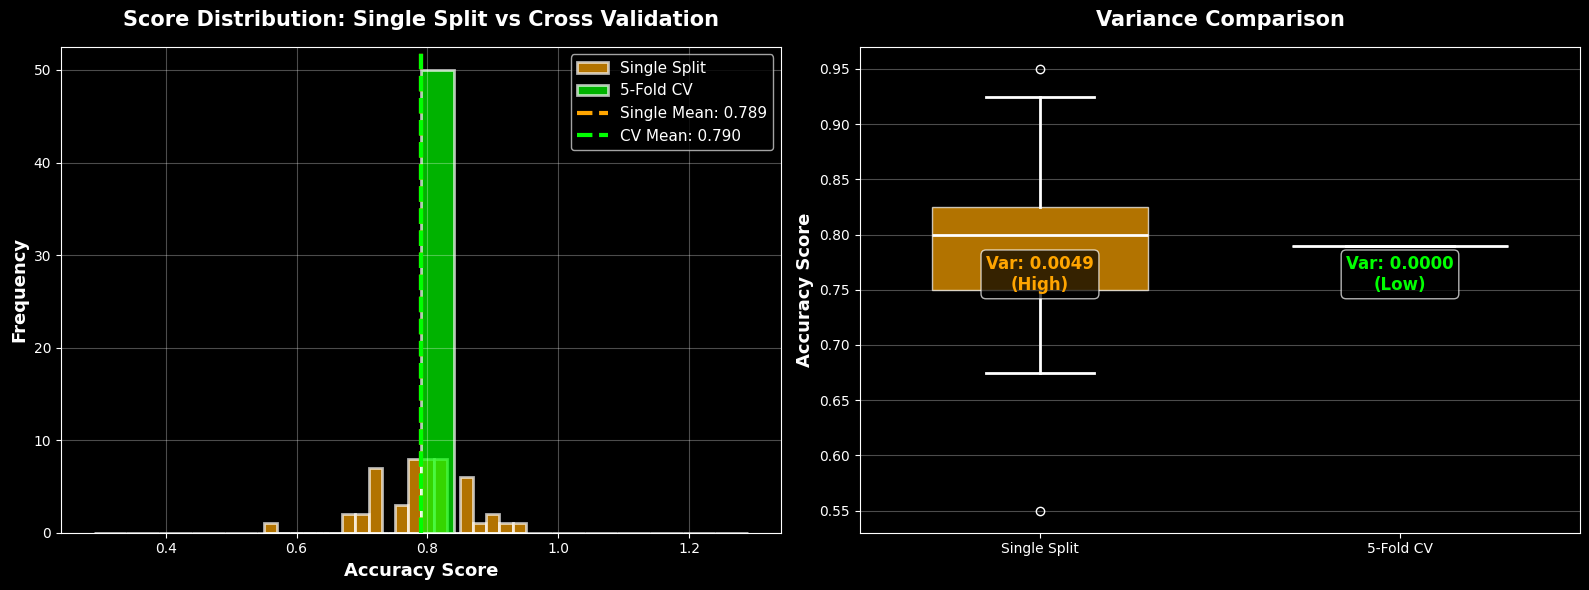


💡 Cross Validation gives MORE RELIABLE estimates!
   Variance reduced by 100.0%


In [4]:
# Generate sample data
X, y = make_classification(n_samples=200, n_features=20, n_informative=15,
                          n_redundant=5, random_state=42)

model = LogisticRegression(max_iter=1000)

# Simulate multiple train-test splits
n_trials = 50
single_split_scores = []

for i in range(n_trials):
    # Random 80-20 split
    indices = np.random.permutation(len(X))
    split_point = int(0.8 * len(X))
    train_idx, test_idx = indices[:split_point], indices[split_point:]
    
    model.fit(X[train_idx], y[train_idx])
    score = model.score(X[test_idx], y[test_idx])
    single_split_scores.append(score)

# K-Fold Cross Validation (multiple trials for comparison)
cv_scores_all = []
for i in range(n_trials):
    cv_scores = cross_val_score(model, X, y, cv=5)
    cv_scores_all.append(cv_scores.mean())

# Statistics
print("Performance Comparison:")
print("="*60)
print(f"Single Split (50 trials):")
print(f"  Mean: {np.mean(single_split_scores):.3f}")
print(f"  Std:  {np.std(single_split_scores):.3f} ⚠️ HIGH variance!")
print(f"  Range: [{np.min(single_split_scores):.3f}, {np.max(single_split_scores):.3f}]\n")

print(f"5-Fold CV (50 trials):")
print(f"  Mean: {np.mean(cv_scores_all):.3f}")
print(f"  Std:  {np.std(cv_scores_all):.3f} ✓ LOWER variance!")
print(f"  Range: [{np.min(cv_scores_all):.3f}, {np.max(cv_scores_all):.3f}]")
print("="*60)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Distributions
ax1 = axes[0]
ax1.hist(single_split_scores, bins=20, alpha=0.7, color='orange', 
        edgecolor='white', linewidth=2, label='Single Split')
ax1.hist(cv_scores_all, bins=20, alpha=0.7, color='lime', 
        edgecolor='white', linewidth=2, label='5-Fold CV')
ax1.axvline(np.mean(single_split_scores), color='orange', 
           linestyle='--', linewidth=3, label=f'Single Mean: {np.mean(single_split_scores):.3f}')
ax1.axvline(np.mean(cv_scores_all), color='lime', 
           linestyle='--', linewidth=3, label=f'CV Mean: {np.mean(cv_scores_all):.3f}')
ax1.set_xlabel('Accuracy Score', fontsize=13, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=13, fontweight='bold')
ax1.set_title('Score Distribution: Single Split vs Cross Validation', 
             fontsize=15, fontweight='bold', pad=15)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Plot 2: Box plot
ax2 = axes[1]
bp = ax2.boxplot([single_split_scores, cv_scores_all], 
                  labels=['Single Split', '5-Fold CV'],
                  patch_artist=True, widths=0.6)

# Color boxes
bp['boxes'][0].set_facecolor('orange')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('lime')
bp['boxes'][1].set_alpha(0.7)

for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    plt.setp(bp[element], color='white', linewidth=2)

ax2.set_ylabel('Accuracy Score', fontsize=13, fontweight='bold')
ax2.set_title('Variance Comparison', fontsize=15, fontweight='bold', pad=15)
ax2.grid(alpha=0.3, axis='y')

# Add variance text
ax2.text(1, 0.75, f'Var: {np.var(single_split_scores):.4f}\n(High)', 
        ha='center', fontsize=12, fontweight='bold', color='orange',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
ax2.text(2, 0.75, f'Var: {np.var(cv_scores_all):.4f}\n(Low)', 
        ha='center', fontsize=12, fontweight='bold', color='lime',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n💡 Cross Validation gives MORE RELIABLE estimates!")
print(f"   Variance reduced by {(1 - np.var(cv_scores_all)/np.var(single_split_scores))*100:.1f}%")

## 4. Different Types of Cross Validation

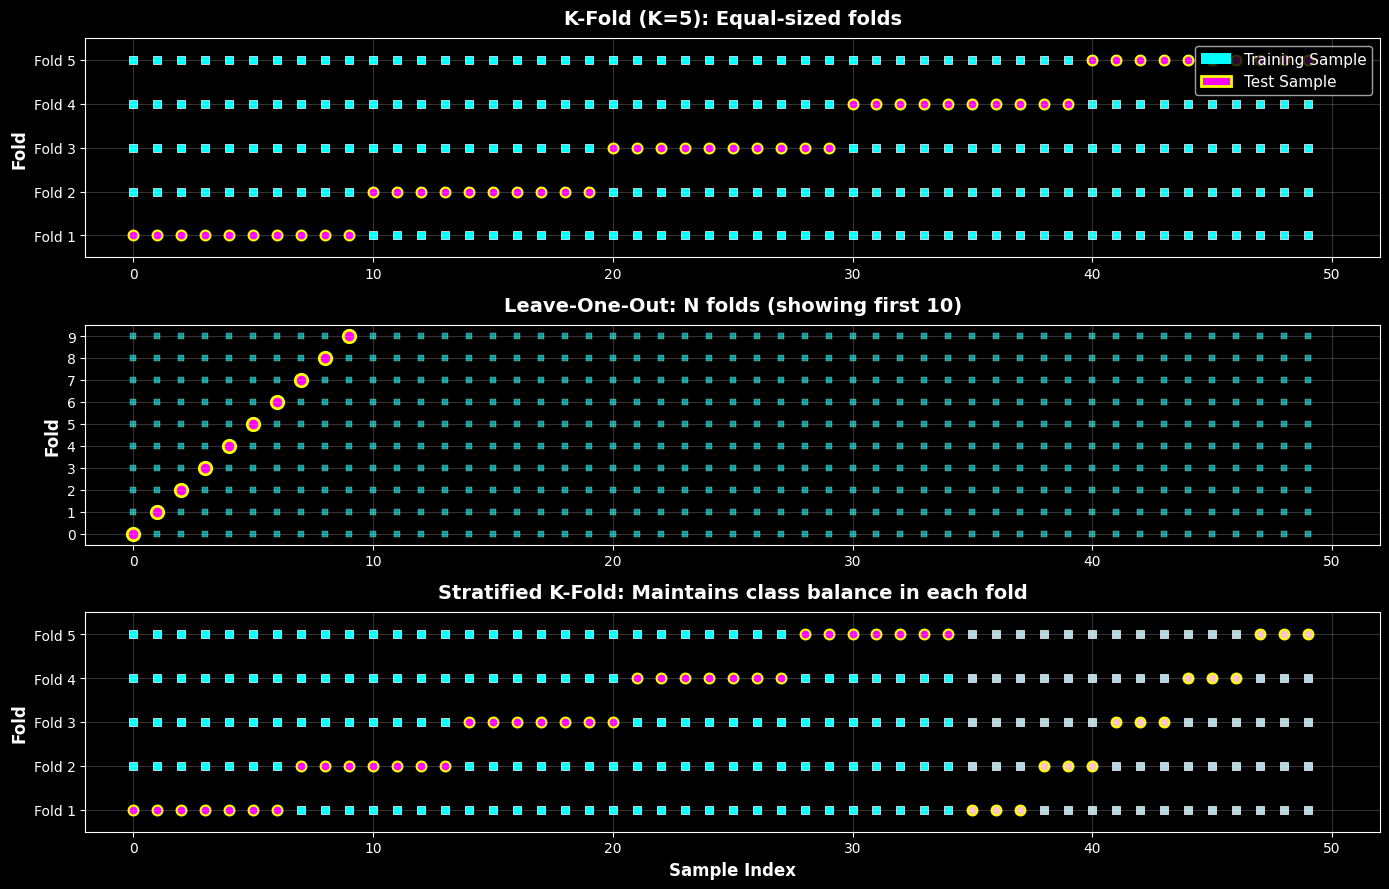


CV Strategies:
K-Fold: Standard, balanced folds
Leave-One-Out: Maximum data usage, expensive (N iterations)
Stratified: Maintains class distribution (for imbalanced data)


In [5]:
# Visualize different CV strategies
n_samples = 50

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

# K-Fold (K=5)
ax = axes[0]
kfold = KFold(n_splits=5, shuffle=False)
for i, (train_idx, test_idx) in enumerate(kfold.split(range(n_samples))):
    # Plot train samples
    ax.scatter(train_idx, [i]*len(train_idx), c='cyan', s=30, 
              marker='s', edgecolors='white', linewidth=0.5)
    # Plot test samples
    ax.scatter(test_idx, [i]*len(test_idx), c='magenta', s=50, 
              marker='o', edgecolors='yellow', linewidth=1.5)

ax.set_ylim(-0.5, 4.5)
ax.set_xlim(-2, n_samples+2)
ax.set_ylabel('Fold', fontsize=12, fontweight='bold')
ax.set_title('K-Fold (K=5): Equal-sized folds', fontsize=14, fontweight='bold', pad=10)
ax.set_yticks(range(5))
ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.grid(alpha=0.2)

# Leave-One-Out (show first 10)
ax = axes[1]
for i in range(10):
    train_idx = [j for j in range(n_samples) if j != i]
    test_idx = [i]
    ax.scatter(train_idx, [i]*len(train_idx), c='cyan', s=15, 
              marker='s', edgecolors='white', linewidth=0.3, alpha=0.6)
    ax.scatter(test_idx, [i]*len(test_idx), c='magenta', s=80, 
              marker='o', edgecolors='yellow', linewidth=2)

ax.set_ylim(-0.5, 9.5)
ax.set_xlim(-2, n_samples+2)
ax.set_ylabel('Fold', fontsize=12, fontweight='bold')
ax.set_title('Leave-One-Out: N folds (showing first 10)', 
            fontsize=14, fontweight='bold', pad=10)
ax.set_yticks(range(10))
ax.grid(alpha=0.2)

# Stratified K-Fold (simulated class imbalance)
ax = axes[2]
# Simulate imbalanced classes
y_imbalanced = np.array([0]*35 + [1]*15)  # 70% class 0, 30% class 1
from sklearn.model_selection import StratifiedKFold
skfold = StratifiedKFold(n_splits=5, shuffle=False)

for i, (train_idx, test_idx) in enumerate(skfold.split(range(n_samples), y_imbalanced)):
    # Color by class
    for idx in train_idx:
        color = 'cyan' if y_imbalanced[idx] == 0 else 'lightblue'
        ax.scatter(idx, i, c=color, s=30, marker='s', 
                  edgecolors='white', linewidth=0.5)
    for idx in test_idx:
        color = 'magenta' if y_imbalanced[idx] == 0 else 'pink'
        ax.scatter(idx, i, c=color, s=50, marker='o', 
                  edgecolors='yellow', linewidth=1.5)

ax.set_ylim(-0.5, 4.5)
ax.set_xlim(-2, n_samples+2)
ax.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Fold', fontsize=12, fontweight='bold')
ax.set_title('Stratified K-Fold: Maintains class balance in each fold', 
            fontsize=14, fontweight='bold', pad=10)
ax.set_yticks(range(5))
ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.grid(alpha=0.2)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='cyan', label='Training Sample'),
    Patch(facecolor='magenta', edgecolor='yellow', linewidth=2, label='Test Sample')
]
axes[0].legend(handles=legend_elements, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

print("\nCV Strategies:")
print("="*60)
print("K-Fold: Standard, balanced folds")
print("Leave-One-Out: Maximum data usage, expensive (N iterations)")
print("Stratified: Maintains class distribution (for imbalanced data)")
print("="*60)

## 5. How to Choose K?

K= 3: Mean=0.825, Std=0.051
K= 5: Mean=0.790, Std=0.078
K=10: Mean=0.800, Std=0.092
K=20: Mean=0.800, Std=0.110


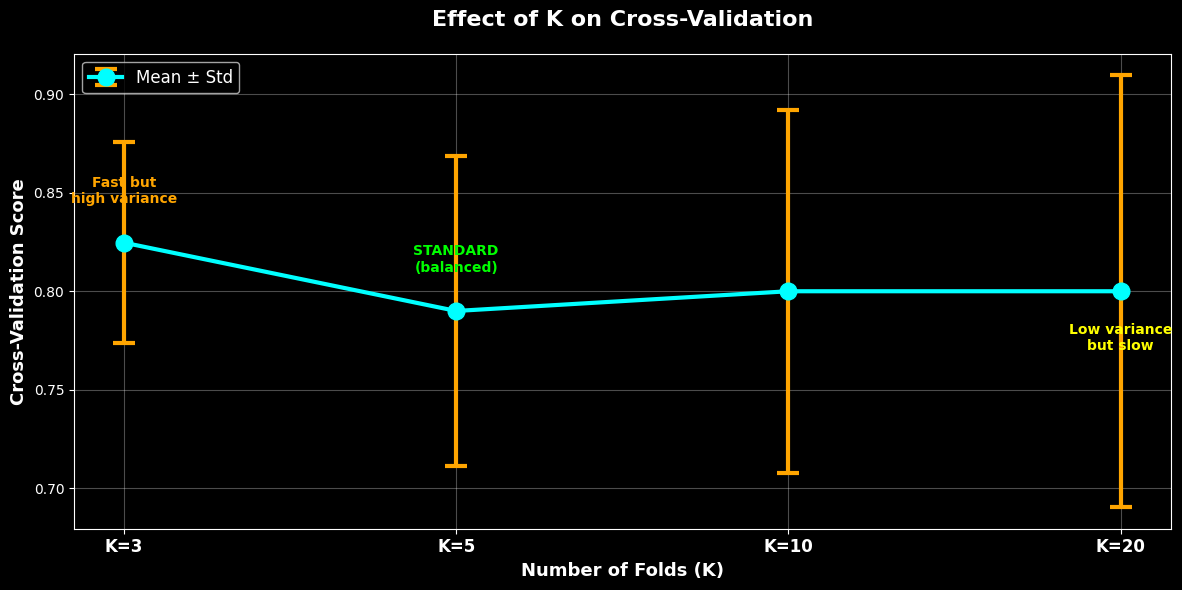


Choosing K:
K=3:  Fast, but higher variance
K=5:  STANDARD choice - good balance! ✓
K=10: Lower variance, more computation
K=N:  Leave-One-Out - maximum data, very slow

Rule of thumb: K=5 or K=10 for most cases


In [6]:
# Compare different K values
k_values = [3, 5, 10, 20]
mean_scores = []
std_scores = []

for k in k_values:
    cv_scores = cross_val_score(model, X, y, cv=k)
    mean_scores.append(cv_scores.mean())
    std_scores.append(cv_scores.std())
    print(f"K={k:2d}: Mean={cv_scores.mean():.3f}, Std={cv_scores.std():.3f}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = range(len(k_values))
ax.errorbar(x_pos, mean_scores, yerr=std_scores, fmt='o-', 
           linewidth=3, markersize=12, capsize=8, capthick=3,
           color='cyan', ecolor='orange', label='Mean ± Std')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'K={k}' for k in k_values], fontsize=12, fontweight='bold')
ax.set_ylabel('Cross-Validation Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Folds (K)', fontsize=13, fontweight='bold')
ax.set_title('Effect of K on Cross-Validation', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

# Add annotations
ax.text(0, mean_scores[0]+0.02, 'Fast but\nhigh variance', 
       ha='center', fontsize=10, color='orange', fontweight='bold')
ax.text(1, mean_scores[1]+0.02, 'STANDARD\n(balanced)', 
       ha='center', fontsize=10, color='lime', fontweight='bold')
ax.text(3, mean_scores[3]-0.03, 'Low variance\nbut slow', 
       ha='center', fontsize=10, color='yellow', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nChoosing K:")
print("="*60)
print("K=3:  Fast, but higher variance")
print("K=5:  STANDARD choice - good balance! ✓")
print("K=10: Lower variance, more computation")
print("K=N:  Leave-One-Out - maximum data, very slow")
print("\nRule of thumb: K=5 or K=10 for most cases")
print("="*60)

## 6. Key Takeaways

### What is Cross Validation?
**Systematic way to evaluate model on different data splits**

### K-Fold Cross Validation:
1. Split data into K equal folds
2. For each fold:
   - Use it as test set
   - Use remaining K-1 folds as training
3. Get K test scores
4. Average them for final estimate

### Why Better than Single Split?
- ✓ Every sample tested exactly once
- ✓ Every sample used for training (K-1)/K times
- ✓ Reduces variance in performance estimate
- ✓ More reliable than single test score
- ✓ Better use of limited data

### Types:

**K-Fold:**
- Standard approach
- K=5 or K=10 typical
- Balanced bias-variance

**Stratified K-Fold:**
- Maintains class distribution
- Essential for imbalanced data
- Prevents biased folds

**Leave-One-Out:**
- K = N (number of samples)
- Maximum data usage
- Very expensive (N iterations)
- High variance

### Choosing K:
- **Small K (3-5)**: Fast, higher variance
- **Medium K (5-10)**: RECOMMENDED - balanced ✓
- **Large K (>10)**: Lower variance, slower
- **K=N**: Leave-one-out, very slow

**Rule of thumb: Use K=5 or K=10**

### When to Use:
- ✓ Always for model evaluation!
- ✓ Hyperparameter tuning
- ✓ Model selection
- ✓ Small datasets (maximize data usage)

### Cost:
- Training time × K
- Worth it for reliable estimates!

### Remember:
**Never use CV data for final testing!**

Best practice:
1. Hold out final test set
2. Use CV on remaining data
3. Test on held-out set once at the end

**Cross Validation = Gold standard for model evaluation!** 🎯